In [15]:
import numpy as np
import pandas as pd

import pickle

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt

In [12]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [6]:
with open(
    "metadata_tokenizer_v1.pkl",
    "rb"
) as f:
    tokenizer=pickle.load(f)

In [7]:
encoder=load_model(
    "metadata_embedding_encoder_v1.keras"
)

In [9]:
metadata_embeddings = np.load(
    "metadata_embeddings.npy"
)

metadata_texts = np.load(
    "metadata_texts.npy"
)

metadata_filenames = np.load(
    "metadata_image_filenames.npy",
    allow_pickle=True
)

In [13]:
max_length=24

def retrieve_similar_metadata(query_metadata, top_k=5):
    query_sequence=tokenizer.texts_to_sequences(
        [query_metadata]
    )

    query_padded=pad_sequences(
        query_sequence,
        maxlen=max_length,
        padding='post'
    )

    query_embedding=encoder.predict(
        query_padded
    )

    similarities=cosine_similarity(
        query_embedding,
        metadata_embeddings
    )[0]

    top_indices=np.argsort(
        similarities
    )[::-1][:top_k]

    results=[]

    for idx in top_indices:

        results.append({

            "metadata":
            metadata_texts[idx],

            "filename":
            metadata_filenames[idx],

            "similarity":
            similarities[idx]
        })

    return results

In [14]:
#test
query = "Nike Air Zoom Running Shoes"

results = retrieve_similar_metadata(
    query,
    top_k=5
)

print(results)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 628ms/step
[{'metadata': np.str_('Nike React Element 87 Sail Light Bone Shoes'), 'filename': 'clean_2019-09-19_10-01-13_UTC.jpg', 'similarity': np.float32(0.9374739)}, {'metadata': np.str_('Nike Air Max 1 Premium Grey Navy Lifestyle Shoes'), 'filename': 'clean_important_1184.jpg', 'similarity': np.float32(0.9302747)}, {'metadata': np.str_('Nike Air Zoom Alphafly NEXT% Dark Grey Green Shoes'), 'filename': 'padded_image_5974.jpg', 'similarity': np.float32(0.86639595)}, {'metadata': np.str_('Nike ACG Mountain Fly Low Brown Tan Trail Shoes'), 'filename': 'clean_important_67.jpg', 'similarity': np.float32(0.8265071)}, {'metadata': np.str_('Nike Air Monarch IV White Grey Cross Training Shoes'), 'filename': 'resized_padded_new_image_1474.jpg', 'similarity': np.float32(0.7816189)}]


In [17]:
num_clusters=8

kmeans=KMeans(
    n_clusters=num_clusters,
    random_state=42
)

cluster_labels=kmeans.fit_predict(
    metadata_embeddings
)

In [18]:
tsne=TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

metadata_2d=tsne.fit_transform(
    metadata_embeddings
)

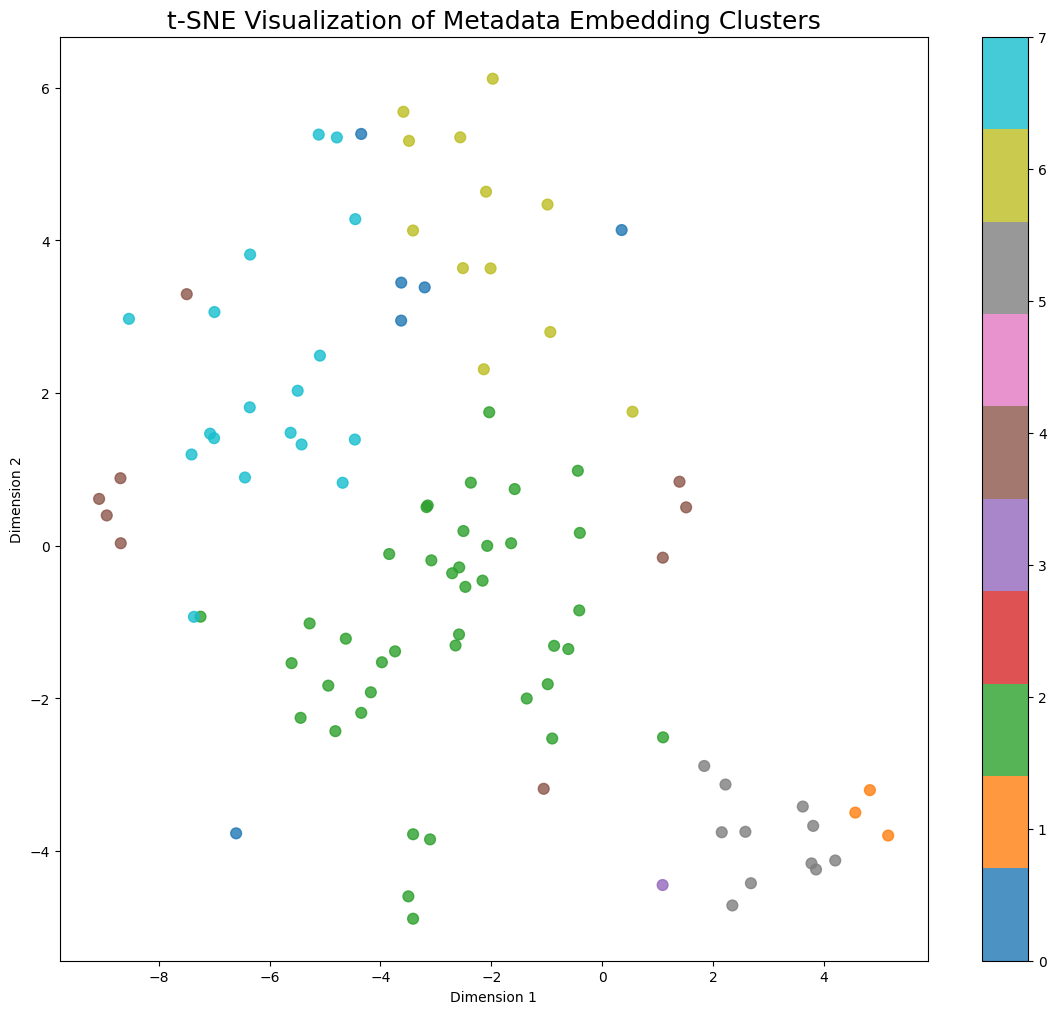

In [19]:
plt.figure(figsize=(14, 12))

scatter = plt.scatter(

    metadata_2d[:, 0],
    metadata_2d[:, 1],

    c=cluster_labels,

    cmap='tab10',

    alpha=0.8,

    s=60
)

plt.title(

    "t-SNE Visualization of Metadata Embedding Clusters",

    fontsize=18
)

plt.xlabel("Dimension 1")

plt.ylabel("Dimension 2")

plt.colorbar(scatter)

plt.show()